<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/BigImgSingnal/uber_fare_prediction_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall torch torchvision torchaudio -y

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [1]:
from google.colab import drive
import torch
import pandas as pd
from torch import nn
import numpy as np
import torch.nn.functional as F


In [2]:
print(torch.version.cuda)
print(torch.cuda.is_available())

None
False


In [3]:
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/Big Img Sig/Uber"

In [27]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
learning_rate = 0.0005
batch_size = 32
experiment_name = 'prova1'

In [6]:
device

'cpu'

In [ ]:
dataset = pd.read_csv(f'{dataset_path}/val.csv', sep='\s+')
len(dataset)

In [ ]:
dataset.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,Distance,month_1,month_2,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,-0.652389,-0.140406,0.136692,-0.139972,0.136307,-0.493901,-0.399941,-0.054162,-0.311289,3.313440,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
1,-0.642289,-0.139333,0.140029,-0.138858,0.140714,-0.493901,1.216060,-0.052260,3.212450,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
2,0.064650,-0.142788,0.134349,-0.141783,0.138648,-0.493901,0.138727,-0.045667,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,4.415280,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
3,-0.652389,-0.142140,0.136223,-0.140815,0.135641,-0.493901,-0.399941,-0.052054,-0.311289,3.313440,...,-0.226377,4.449900,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
4,0.569606,-0.142787,0.136007,-0.138969,0.137039,-0.493901,1.216060,-0.045906,3.212450,-0.301802,...,4.417420,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047


In [ ]:
dataset_columns = dataset.columns.tolist()
dataset_columns

In [ ]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self, csv):
    self.df = pd.read_csv(csv, sep='\s+')
    self.input_cols = self.df.columns.drop('fare_amount').tolist()
    self.output_cols = ['fare_amount']

  def __len__(self):
    return len(self.df)
  def __getitem__(self, index):
    # read row, split in input and output and convert in tensors
    row= self.df.iloc[index]
    # split in input
    input_rows = row[self.input_cols]
    # split in output
    output_rows = row[self.output_cols]
    # convert input & output in tensors
    features = torch.tensor(input_rows.to_numpy(), dtype=torch.float32)
    ground_throuthg = torch.tensor(output_rows.to_numpy(), dtype=torch.float32)
    return features, ground_throuthg

In [54]:
# create train and validation datasets
train_ds = Dataset(f'{dataset_path}/train.csv')
val_ds =  Dataset(f'{dataset_path}/val.csv')

### Explore the dataset

In [ ]:
val_ds.df.shape

(100, 51)

In [ ]:
val_ds.__getitem__(0)

In [ ]:
val_ds.df[:2]

In [ ]:
val_ds.df.iloc[0]

In [ ]:
xx, yy = val_ds.__getitem__(0)

In [ ]:
yy

tensor([-0.6524])

In [ ]:
xx

In [ ]:
val_ds.output_cols

['fare_amount']

In [ ]:
val_ds.input_cols[:5]

In [ ]:
val_ds.__len__()

100

In [ ]:
val_ds.df.tail()

### Prepare the dataset

In [55]:
train_ds.df.shape, val_ds.df.shape

((159990, 51), (19998, 51))

In [56]:
# prepare the datast loader with torch data loader for training and testing
train_data_loader = torch.utils.data.DataLoader(dataset=train_ds,
                                                batch_size=batch_size,
                                                shuffle=True,
                                                drop_last=True,
                                                num_workers=2)
test_data_loader = torch.utils.data.DataLoader(dataset=val_ds,
                                                batch_size=batch_size,
                                                shuffle=True,
                                                drop_last=True,
                                                num_workers=2)

In [57]:
len(train_data_loader.dataset), len(test_data_loader.dataset), f"Number of Batches: {len(train_data_loader)}"

(159990, 19998, 'Number of Batches: 4999')

#### Exploare the inputs and ground throught data

In [ ]:
for batch, (X, y) in enumerate(train_data_loader):
  print(f'batch: {batch}\n X: {X[:1][0][:4]}\n y: {y[:1]}\n Feature shape: {X.shape} \n Atribute shape: {y.shape}')
  if batch>=5: break

### Creating Models

In [58]:
np.shape(train_ds.input_cols)

(50,)

In [59]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    # Super will automatically call the parrent of the class from nn.Module and execute them by init method
    super(NeuralNetwork, self).__init__()
    # initialize the layer
    self.layer1 = nn.Linear(in_features=50, out_features=128)
    self.layer2 = nn.ReLU()
    self.layer3 = nn.Linear(in_features=128, out_features=64)
    self.layer4 = nn.ReLU()
    self.layer5 = nn.Linear(in_features=64, out_features=32)
    self.layer6 = nn.ReLU()
    # output layer
    self.layer7 = nn.Linear(in_features=32, out_features=1)

  # how data will pass through network
  def forward(self, x):
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.layer5(x)
    x = self.layer6(x)
    x = self.layer7(x)
    return x

# Move the network in GPU
model = NeuralNetwork().to(device)
model

NeuralNetwork(
  (layer1): Linear(in_features=50, out_features=128, bias=True)
  (layer2): ReLU()
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (layer4): ReLU()
  (layer5): Linear(in_features=64, out_features=32, bias=True)
  (layer6): ReLU()
  (layer7): Linear(in_features=32, out_features=1, bias=True)
)

#### Explore the model

In [ ]:
# Test the Network
md = NeuralNetwork()
md

In [ ]:
# Define a 10 random input element
inp = torch.rand(10, 50)
inp.shape

torch.Size([10, 50])

In [ ]:
# forward to the network
outp = md(inp)
outp, outp.shape, f"Argmax: { outp.argmax(1)}"

In [ ]:
# let's move the network in GPU
md.to(device=device)
# define a random batch
inp = torch.rand(10, 50)
inp = inp.to(device)
# forward to network
outp = md(inp)
md, outp, outp.shape

### Optimizing the Model Parameters
To train a model, we need a loss function and an optimizer.



In [60]:
loss_fun = nn.functional.l1_loss
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

### Define the Train model preccess

In [61]:
def train_model(dataloader, model, loss_fun, optimizer, verbose=0):
  size = len(dataloader.dataset)
  model.train() # <-- Set model to training mode
  total_loss =0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    # Compute the prediction error
    pred = model(X)
    loss = loss_fun(input=pred, target=y)

    # Backpropagation
    loss.backward() # <-- compute the gradient
    # update weights
    optimizer.step() # <-- optimize NN by 1 batch
    optimizer.zero_grad() # <-- resets the gradients to zero before the next update
    total_loss += loss.item()

    if verbose>0 & batch % 100 == 0:
      loss, current = loss.item(), (batch+1)*len(X)
      print(f'loss: {loss:>7f}  [{current:>5d}/{size:>5d}]')
  train_loss = total_loss / len(dataloader)
  return train_loss

**We also check the model’s performance against the test dataset to ensure it is learning.**



In [62]:
def validate_regression(model, dataloader):
    """
    Evaluate a regression model on a dataloader.
    Returns:
        avg_loss: average L1 loss
        r2_score: R² metric
        mape: mean absolute percentage error in %
          how far off your predictions are from the true values
           lower percentages indicating better performance
        ```
        MAPE=(1/n)∑(∣yi​−y^​i​∣​)/​∣yi​∣

        ```
    """
    model.eval()  # evaluation mode
    total_loss = 0
    total_error = 0   # for R²
    total_var = 0     # for R²
    total_mape = 0
    total_samples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            # L1 loss
            batch_loss = F.l1_loss(pred, y, reduction='sum')
            total_loss += batch_loss.item()

            # R² score calculation
            y_mean = y.mean()
            total_var += ((y - y_mean) ** 2).sum().item()
            total_error += ((y - pred) ** 2).sum().item()

            # MAPE calculation
            total_mape += (torch.abs((y - pred) / (y + 1e-8))).sum().item()

            total_samples += y.numel()

    # Average metrics
    avg_loss = total_loss / total_samples # <-- Avg loss → standard MSE/MAE for regression
    r2 = 1 - (total_error / total_var) # <-- 1 means perfect prediction, 0 means model predicts just the mean, negative → model is worse than mean
    mape = (total_mape / total_samples) * 100  # percentage

    model.train()  # back to training mode
    return avg_loss, r2, mape

**Train the model**

In [ ]:
epoch = 50
train_losses = []
val_losses = []
for t in range(epoch):
  print(f'Epoch {t+1} \n ---------------------------------------------------------------------')
  train_loss = train_model(dataloader=train_data_loader, model=model, loss_fun=loss_fun, optimizer=optimizer)
  train_losses.append(train_loss)
  avg_loss, r2_score, mape = validate_regression(dataloader=test_data_loader, model=model )
  val_losses.append(avg_loss)
  print(f"Validation: \n L1 Loss: {avg_loss:.4f}\t R²: {r2_score:.4f}\t MAPE: {mape:.2f}% \n")

# save model
torch.save(model.state_dict(), 'mode.path')
print("Done!")


In [ ]:
# Output of the training procces
# Epoch 48
#  ---------------------------------------------------------------------
# Validation:
#  L1 Loss: 0.2261	 R²: 0.7221	 MAPE: 121.24%

# Epoch 49
#  ---------------------------------------------------------------------
# Validation:
#  L1 Loss: 0.2256	 R²: 0.7249	 MAPE: 116.74%

# Epoch 50
#  ---------------------------------------------------------------------
# Validation:
#  L1 Loss: 0.2296	 R²: 0.7227	 MAPE: 122.97%

**Evaluate the model loss and accuracy history**

* train_loss ↓ and val_loss ↓ → good learning

* train_loss ↓ but val_loss ↑ → overfitting

* both high and flat → underfitting

<Axes: title={'center': 'Loss curve'}, xlabel='No epochs', ylabel='Loss value'>

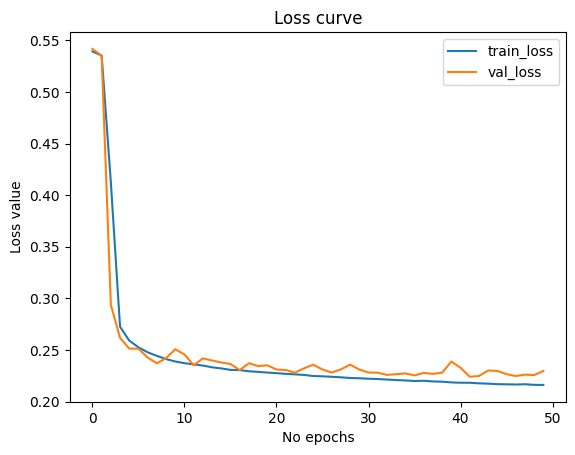

In [68]:
history= pd.DataFrame({'train_loss': train_losses, 'val_loss': val_losses})
history.plot(title="Loss curve", xlabel="No epochs", ylabel="Loss value")

**Predtion**

In [23]:
# Load the test dataset
test_data =  Dataset(f'{dataset_path}/test.csv')

In [24]:
# Create a test dataloader
test_dataloaer = torch.utils.data.DataLoader(dataset=test_data,
                                             batch_size=batch_size,
                                             shuffle=False,
                                             drop_last=False,
                                             num_workers=2)

In [69]:
# Load the model
new_model = NeuralNetwork().to(device)
new_model.load_state_dict(state_dict=torch.load('/content/drive/MyDrive/Big Img Sig/Uber/mode.path', weights_only=True))

<All keys matched successfully>

In [70]:
# Evaluate loaded modle on test dataset
avg_loss, r2_score, mape = validate_regression(dataloader=test_dataloaer, model=new_model )
print(f"Validation: \n L1 Loss: {avg_loss:.4f}\t R²: {r2_score:.4f}\t MAPE: {mape:.2f}% \n")

Validation: 
 L1 Loss: 0.2285	 R²: 0.7034	 MAPE: 123.57% 

